<a href="https://colab.research.google.com/github/IngLuisGarcia17/S7-Project_ConnectaTel/blob/main/Copia_de_S7_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ConnectaTel Analysis

As a **data analyst**, your goal is to evaluate the **behavior of customers** of a telecommunications company in Latin America, ConnectaTel.

We will work with information recorded **until the year 2024**, which will allow us to analyze the business behavior within that period.

To do this, you will work with three datasets:

- **plans.csv** → current plan information (price, included minutes, included GB, extra cost)
- **users.csv** → customer information (age, city, registration date, plan, churn)
- **usage.csv** → **real usage** details of services (calls and messages)

You must **explore**, **clean**, and **analyze** this data to build a **statistical profile** of customers, detect **atypical behaviors**, and create **customer segments**.

This analysis will allow you to **identify consumption patterns**, **design retention strategies**, and **suggest improvements to the plans** offered by the company.

> 💡 Before starting, remember to think **programmatically**: what steps do you need? In what order? What do you want to measure and why?

---
## 🧩 Step 1: Load and Explore

Before cleaning or combining the data, it is necessary to **familiarize yourself with the structure of the three datasets**.
In this stage, you will validate that the files load correctly, learn about their columns and data types, and detect possible inconsistencies.

### 1.1 Data Loading and Quick View

**🎯 Objective:**
Have the **3 datasets ready in memory**, understand their content, and perform a preliminary review.

**Instructions:**
- Import the necessary libraries (e.g., `pandas`, `seaborn`, `matplotlib.pyplot`)
- Load the CSV files using `pd.read_csv()`:
  - **`/datasets/plans.csv`**
  - **`/datasets/users_latam.csv`**
  - **`/datasets/usage.csv`**
- Save the DataFrames to variables: `plans`, `users`, `usage`.
- Display the first rows of each DataFrame using `.head()`.

In [53]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [54]:
# load files
plans = pd.read_csv('sample_data/plans_raw.csv')
users = pd.read_csv('sample_data/users_latam_raw.csv')
usage = pd.read_csv('sample_data/usage_raw.csv')

In [55]:
# display the first 5 rows of plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [56]:
# display the first 5 rows of users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [57]:
# display the first 5 rows of usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** If you don't use `print()`, the table will look better.

### 1.2 Exploration of Dataset Structure

**🎯 Objective:**
Understand the **structure of each dataset**, review how many rows and columns they have, identify the **data types** of each column, and detect possible **inconsistencies or null values** before starting the analysis.

**Instructions:**
- Check the **number of rows and columns** of each dataset using `.shape`.
- Use `.info()` on each DataFrame to get a **complete summary** of columns, data types, and non-null values.

In [58]:
# check the number of rows and columns for each dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [59]:
# plans inspection with .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [60]:
# users inspection with .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [61]:
# usage inspection with .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩 Step 2: Identify Data Quality Issues

### 2.1 Review of Null Values

**🎯 Objective:**
Detect the presence and magnitude of missing values to evaluate if they affect the analysis or require imputation/deletion.

**Instructions:**
- Count null values per column for each dataset.
- Calculate the proportion of nulls per column for each dataset.

The `plans` dataset only has 2 rows and can be observed to have no missing values, so it does not need additional exploration.

<br>
<details>
<summary>Click to see the hint</summary>
Use `.isna().sum()` to count null values and `.isna().mean()` to calculate the proportion.
</details>

In [62]:
# count of nulls for users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [63]:
# count of nulls for usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comments**:

---

**Null values**
- Churn has 88% of nulls, we will let as nulls until review any tendence.
- City has 11% of nulls, we will let as null for later change to 'uknown'.
- Date has only 50 rows as null, we will delete so they don't affect segmentations.
- Durantion and lenght have around 50% of cases with null, we will evaluate wether to imput then with median or mean depending of distribution.

### 2.2 Detection of Invalid Values and Sentinels

🎯 **Objective:**
Identify sentinels: values that should not be in the dataset.

**Instructions:**
- Explore the numerical columns with **a statistical summary** and briefly describe what you found.
- Explore the **relevant** categorical columns, reviewing their unique values and briefly describe what you found.

The `plans` dataset only has 2 rows, so it does not need additional exploration.

In [64]:
# explore numerical columns of users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- The `user_id` column has 4000 users.
- The `age` column has sentinels in -999

In [65]:
# explore numerical columns of usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- The `id` and `user_id` columns have 40000 registers
- The columns `duration` and `lenght` have minimun values as 0

In [66]:
# explore categorical columns of users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"Unique values in column '{columna}':")
    print(users[columna].unique())
    print()


Unique values in column 'city':
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Unique values in column 'plan':
['Basico' 'Premium']



- The `city` column has 'nan' and '?' values.
- The `plan` column only has two categories, no neccesary corrections.

In [67]:
# explore categorical column of usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- The `type` column only has two categories, no neccesary corrections.

---
✍️ **Comment**:

**Invalid values or sentinels**
- Duration and lenght have sentinels as 0, that need change after check they missingess.
- City has sentinels as '?' and nan, we will change for unknows.

### 2.3 Date Review and Standardization

**🎯 Objective:**
Ensure that date columns are correctly formatted and detect out-of-range years that indicate data entry errors.

**Instructions:**
- Convert date columns to date type and ensure the code is error-proof.
- Review how many times each year appears.
- Identify impossible dates (e.g., future or negative years).

Note that we have data recorded until the year 2024.

In [68]:
# Convert `reg_date` column of users to date type
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [69]:
# Convert `date` column of usage to date type
usage['date'] = pd.to_datetime(usage['date'], errors= 'coerce')

In [70]:
# Review the years present in `reg_date` of users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024], dtype=int32)

In [71]:
total_2026 = (users['reg_date'].dt.year == 2026).sum()
print(f"Total of registers in 2026: {total_2026}")

Total of registers in 2026: 40


In [72]:
df_2026 = users[users['reg_date'].dt.year == 2026]
df_2026

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"
320,10320,Sofia,Garcia,74,GDL,2026-05-10,Premium,NaN
326,10326,Mariana,Torres,51,Medellín,2026-05-10,Premium,NaN
505,10505,Luis,Garcia,75,CDMX,2026-05-10,Basico,NaN
527,10527,Carlos,Torres,71,MTY,2026-05-10,Basico,NaN
646,10646,Luis,Ramirez,50,CDMX,2026-05-10,Premium,NaN


In `reg_date`, we have 40 registers under 2026, that's imposible date.

In [73]:
# Review the years present in `date` of usage
usage['date'].dt.year.unique()

array([2024.,   nan])

In [74]:
df_nan= usage[usage['date'].isna()]
df_nan

,id,user_id,type,date,duration,length
2854,2855,12193,text,NaT,NaN,64.0
3443,3444,10775,text,NaT,NaN,69.0
3808,3809,10916,text,NaT,NaN,23.0
3987,3988,12175,call,NaT,2.43,NaN
4114,4115,12527,text,NaT,NaN,67.0
6287,6288,13676,call,NaT,1.64,NaN
6445,6446,12553,text,NaT,NaN,39.0
6584,6585,12542,text,NaT,NaN,43.0
7879,7880,11347,text,NaT,NaN,35.0
8204,8205,10099,text,NaT,NaN,41.0


In `date`, we have 50 registers under nan.

✍️ **Comment**:

**Out-of-range dates**
- reg_date has 40 registers under 2026, we will change to NA.
- date has 50 registers with nan, we will delete, we will keep as NA

---

## 🧩 Step 3: Basic Data Cleaning

### 3.1 Correct Sentinels and Impossible Dates
**🎯 Objective:**
Apply cleaning rules to replace sentinel values and correct impossible dates.

**Instructions:**
- In `age`, replace the sentinel **-999** with the median.
- In `city`, replace the sentinel `"?"` with null values (`pd.NA`).
- Mark out-of-range dates as nulls (`pd.NA`).

In [75]:
# Replace -999 with the median of age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verify changes
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [76]:
# Replace ? with NA in city
users['city'] = users['city'].replace('?', pd.NA)
# Verify changes
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [77]:
# We unify in one NAN
users['city'] = users['city'].fillna(np.nan)
users['city'].unique()

array(['Medellín', nan, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [78]:
# Mark future dates as NA for reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NA
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NA

# Verify changes
print(f"futures dates in users: {(users['reg_date'].dt.year > 2024).sum()}")
print(f"futures dates in usage: {(usage['date'].dt.year > 2024).sum()}")

futures dates in users: 0
futures dates in usage: 0


### 3.2 Correct Sentinels and Impossible Dates
**🎯 Objective:**
Decide what to do with null values based on their proportion and relevance.

**Instructions:**
- Verify if the nulls in `duration` and `length` are **MAR** (Missing At Random) by checking if they depend on the `type` column.
  If you confirm they are MAR, **leave them as nulls** and justify the decision.

In [79]:
# MAR verification in usage (Missing At Random) for duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

,duration
type,
text,0.999276
call,0.000000


In [80]:
# MAR verification in usage (Missing At Random) for length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

,length
type,
call,0.99933
text,0.00000


Nulls of `duration` and `length` coresponds to type text.

---

## 🧩 Step 4: User Usage Summary Statistics


### 4.1 Grouping by Usage Behavior

🎯**Objective**: Summarize key variables from the `usage` table **per user**, creating metrics that represent their actual historical usage behavior.

**Instructions:**:
1. Build an aggregated table of `usage` by `user_id` that includes:
- total number of messages
- total number of calls
- total call minutes

2. Rename the columns to have clear names:
- `cant_mensajes` (message count)
- `cant_llamadas` (call count)
- `cant_minutos_llamada` (call minutes count)
3. Combine this table with `users`.

In [81]:
# Auxiliary columns
usage["is_text"] = (usage["type"] == "text").astype(int) # to know the total messages
usage["is_call"] = (usage["type"] == "call").astype(int) # to know the total calls


# Group information by user
usage_agg = usage.groupby('user_id').agg(
    message_count = ('is_text', 'sum'),
    call_count = ('is_call', 'sum'),
    call_minutes_count = ('duration', 'sum')
).reset_index()

# observe result
usage_agg.head(3)

,user_id,message_count,call_count,call_minutes_count
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [82]:
# Combine the aggregated table with the users dataset
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Verify changes
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_minutes_count
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 User Statistical Summary for 2024

🎯 **Objective:** Analyze the numerical and categorical columns of users, to identify ranges, extreme values and data distribution before continuing with the analysis.

**Instructions:**
1. For relevant **numerical** columns, obtain a statistical summary (mean, median, minimum, maximum, etc.).
2. For the **categorical** column `plan`, review the distribution in **percentages** of each category.

In [83]:
# Statistical summary of numerical columns
user_profile[['age','message_count','call_count','call_minutes_count']].describe()

,age,message_count,call_count,call_minutes_count
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [84]:
user_profile['message_count'].isna().sum()

np.int64(1)

In [85]:
user_profile_nan = user_profile[user_profile['message_count'].isna()]
user_profile_nan

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_minutes_count
1082,11082,Luis,Gomez,39,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,NaN,NaN,NaN


In [86]:
# Percentage distribution of plan type
user_profile['plan'].value_counts(normalize= True)


,proportion
plan,
Basico,0.64875
Premium,0.35125


---

## 🧩 Step 5: Visualization of Distributions (Usage and Customers) and Outliers


### 5.1 Visualization of Distributions

🎯 **Objective:**
Visually understand how key **usage** and **customer** variables behave, observe if there are differences according to the plan type, and analyze the **shape of the distribution**.

**Instructions:**
Plot **histograms** for the following columns:
- `age` (user age)
- `cant_mensajes` (message count)
- `cant_llamadas` (call count)
- `total_minutos_llamada` (total call minutes)

After each graph, write an **insight** regarding the plan and the variable, for example:
- "Within the Premium plan, there is a higher proportion of..."
- "Basic users tend to make ... calls and send ... messages." or "No pattern exists."
- What type of distribution does it have? (symmetric, right-skewed or left-skewed)

**Hint**
For each histogram,
- Use `hue='plan'` to see how the distributions vary according to the plan (Basic or Premium).
- Use `palette=['skyblue','green']`
- Add title and labels

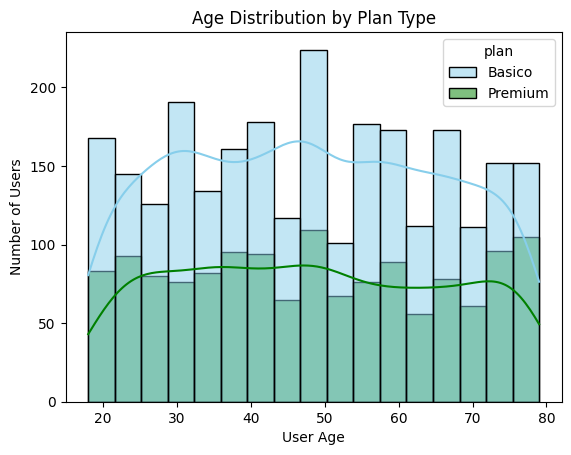

In [87]:
# Histogram to visualize age
sns.histplot(data = user_profile,
             x = 'age',
             hue = 'plan',
             palette = ['skyblue', 'green'],
             kde = True)
plt.title('Age Distribution by Plan Type')
plt.xlabel('User Age')
plt.ylabel('Number of Users')
plt.show()

💡Insights:
- The data follows a normal distribution centered around a mean of 48 years for both types. The majority of customers exhibit stable and predictable behavior. Therefore, the mean represents the business reality.

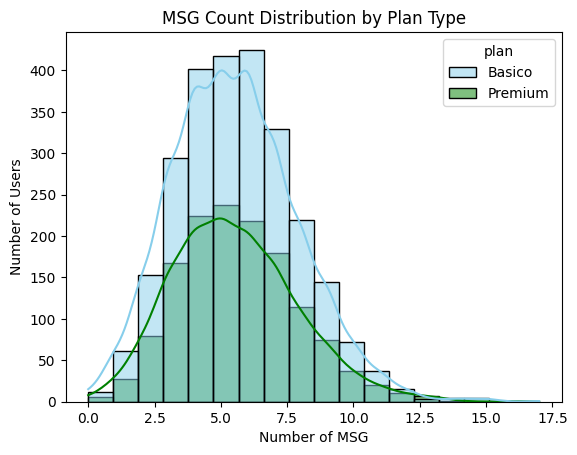

In [88]:
# Histogram to visualize message count
sns.histplot(data= user_profile,
             x= 'message_count',
             hue= 'plan',
             palette= ['skyblue','green'],
             kde= True,
             bins = 18)
plt.title('MSG Count Distribution by Plan Type')
plt.xlabel('Number of MSG')
plt.ylabel('Number of Users')
plt.show()

💡Insights:
- Right-skewed, a small group of high-volume customers drives the majority of usage (long-tail effect).

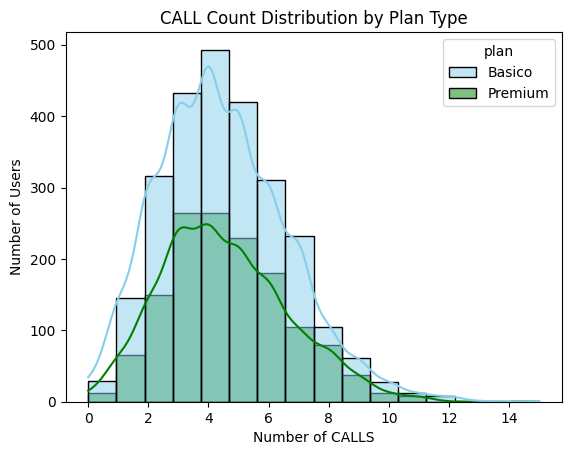

In [89]:
# Histogram to visualize call count
sns.histplot(data= user_profile,
             x='call_count',
             hue= 'plan',
             palette= ['skyblue','green'],
             kde= True,
             bins = 16)
plt.title('CALL Count Distribution by Plan Type')
plt.xlabel('Number of CALLS')
plt.ylabel('Number of Users')
plt.show()

💡Insights:
- Right-skewed, a small group of high-volume customers drives the majority of sales (long-tail effect).

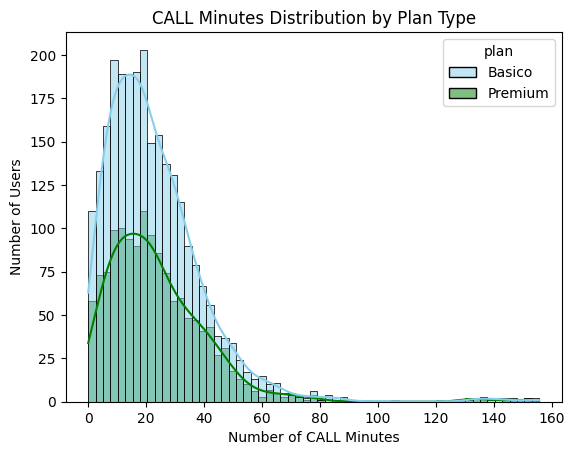

In [90]:
# Histogram to visualize total call minutes
sns.histplot(data= user_profile,
             x='call_minutes_count',
             hue= 'plan',
             palette= ['skyblue','green'],
             kde= True)
plt.title('CALL Minutes Distribution by Plan Type')
plt.xlabel('Number of CALL Minutes')
plt.ylabel('Number of Users')
plt.show()

💡Insights:
- Right-skewed, a small group of high-volume customers drives the majority of usage (long-tail effect).
- We have some outliers in right side.

### 5.2 Outlier Identification

🎯 **Objective:**
Detect extreme values in key **usage** and **customer** variables that could affect the analysis, and decide if they require cleaning or further review.

**Instructions:**
- Use **boxplots** to visually identify outliers in the following columns:
  - `age`
  - `cant_mensajes` (message count)
  - `cant_llamadas` (call count)
  - `total_minutos_llamada` (total call minutes)
- Create a **for loop** to automatically generate the 4 boxplots.
<br>

- After creating the graph, answer if **outliers exist or not** in the variables.
- If there are outliers, create another loop to calculate the limits of those columns using the **IQR method** and decide what to do with them.
  - If there are only one-sided outliers, it is not necessary to calculate both limits.

**Hint:**
- Inside the loop, use `plt.title(f'Boxplot: {col}')` so that the title changes according to the column.

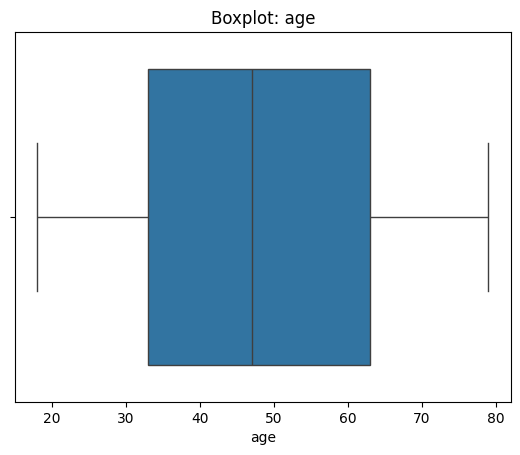

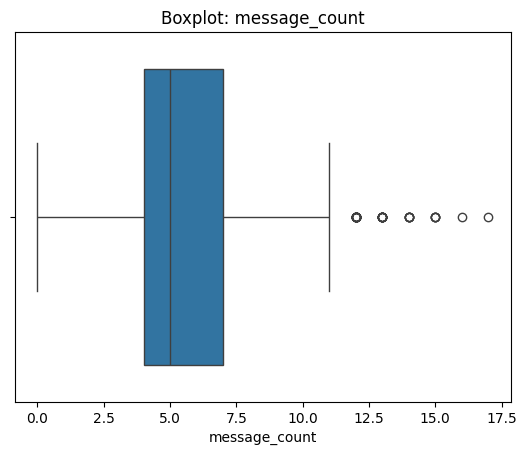

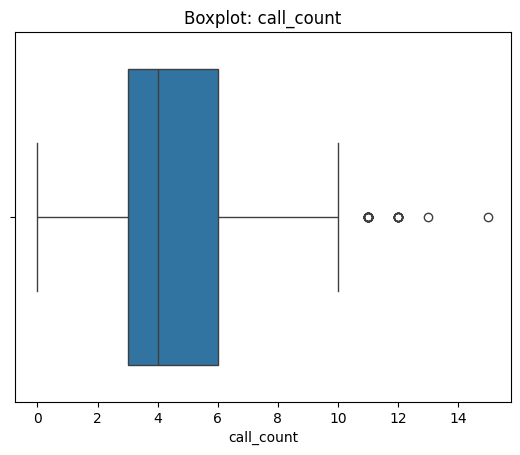

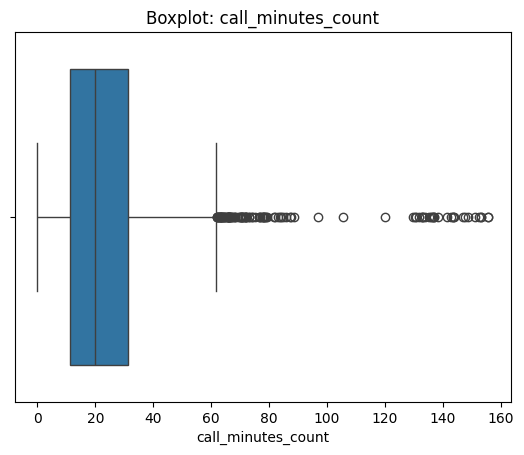

In [91]:
# Visualizing using BoxPlot
numeric_cols = ['age', 'message_count', 'call_count', 'call_minutes_count']

for columna in numeric_cols:
    sns.boxplot(data=user_profile, x=columna)
    plt.title(f'Boxplot: {columna}')
    plt.show()

💡Insights:
- Age: doesn't present any outlier.
- count_message: Has outliers.
- call_count: Has outliers.
- call_minutes_count: Has outliers.

In [92]:
# Calculate limits using the IQR method
limit_cols = ['message_count', 'call_count', 'call_minutes_count']

for columna in limit_cols:
    q1 = user_profile[columna].quantile(0.25)
    q3 = user_profile[columna].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    print(f"Column: {columna}")
    print(f"Lower limit: {lower_limit}")
    print(f"Upper limit: {upper_limit}")
    print()




Column: message_count
Lower limit: -0.5
Upper limit: 11.5

Column: call_count
Lower limit: -1.5
Upper limit: 10.5

Column: call_minutes_count
Lower limit: -19.322500000000005
Upper limit: 61.8575



In [93]:
# Review the upper limits and the max, to make the decision to keep or not keep the outliers
user_profile[limit_cols].describe()

,message_count,call_count,call_minutes_count
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- message_count: keep due to value customer use.
- call_count: keep due to value customer use.
- call_minutes_count: keep due to value customer use.

---

## 🧩 Step 6: Customer Segmentation

### 6.1 Customer Segmentation by Usage

🎯 **Objective:** Classify each user into a usage group (Low usage, Medium usage, High usage) based on the number of calls and messages recorded.

**Instructions:**
- Create a new column called `usage_group` (usage group) in the `user_profile` dataframe.
- Use logical comparisons (<, >) to evaluate call and message conditions and assign:
  - `'Low usage'` (Low usage) when calls < 5 and messages < 5
  - `'Medium usage'` (Medium usage) when calls < 10 and messages < 10
  - `'High usage'` (High usage) for the rest of the cases

In [94]:
# Create usage_group column
def classify_usage(row):
    if row['call_count'] < 5 and row['message_count'] < 5:
        return 'Low usage'
    elif row['call_count'] < 10 and row['message_count'] < 10:
        return 'Medium usage'
    else:
        return 'High usage'

user_profile['usage_group'] = user_profile.apply(classify_usage, axis=1)


In [95]:
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_minutes_count,usage_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medium usage
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,High usage
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medium usage
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,High usage
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Low usage


### 6.2 Customer Segmentation by Age

🎯 **Objective:** Classify each user into an **age group**.

**Instructions:**
- Create a new column called `grupo_edad` (age group) in the `user_profile` dataframe.
- Use logical comparisons (<, >) to evaluate the conditions and assign:
  - `'Joven'` (Young) when age < 30
  - `'Adulto'` (Adult) when age < 60
  - `'Adulto Mayor'` (Elderly) for the rest of the cases

In [96]:
# Create age_group column
def classify_age(row):
  if row['age'] < 30:
    return 'Young'
  elif row['age'] < 60:
    return 'Adult'
  else:
    return 'Elderly'

user_profile['age_group'] = user_profile.apply(classify_age, axis = 1)


In [97]:
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,message_count,call_count,call_minutes_count,usage_group,age_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medium usage,Adult
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,High usage,Adult
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medium usage,Adult
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,High usage,Elderly
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Low usage,Elderly


### 6.3 Visualization of Customer Segmentation

🎯 **Objective:** Visualize the distribution of users according to the created groups: **grupo_uso** (usage group) and **grupo_edad** (age group).

**Instructions:**
- Create two graphs for the categorical variables `grupo_uso` and `grupo_edad`.
- Add title and labels to the axes in each graph.

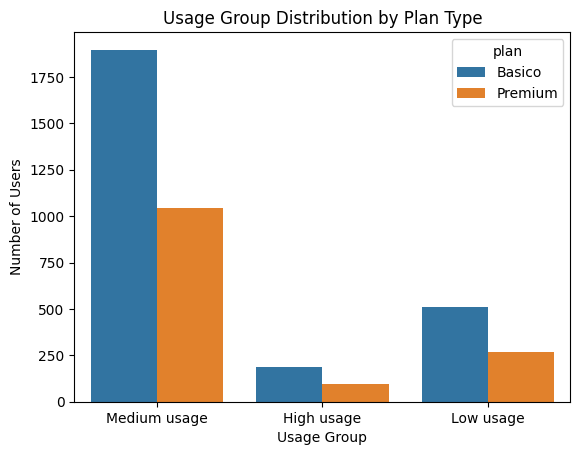

In [98]:
# Visualization of segments by usage
sns.countplot(data = user_profile,
              x = 'usage_group',
              hue = 'plan')
plt.title('Usage Group Distribution by Plan Type')
plt.xlabel('Usage Group')
plt.ylabel('Number of Users')

plt.show()

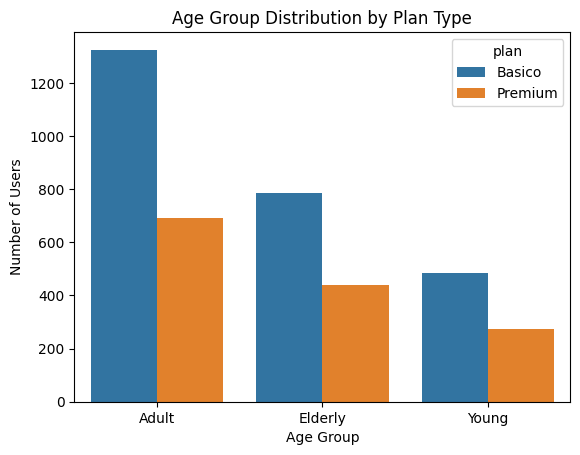

In [99]:
# Visualization of segments by age
sns.countplot(data = user_profile,
              x = 'age_group',
              hue = 'plan')
plt.title('Age Group Distribution by Plan Type')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')

plt.show()


---
## 🧩 Step 7: Executive Insight for Stakeholders

🎯 **Objective:** Translate analysis findings into actionable business conclusions, focusing on segmentation, usage patterns, and commercial opportunities.

**Questions to answer:**
- What problems did the data originally have? What percentage, or number of rows, of that column did they represent?


- What customer segments did you identify and how do they behave according to their age and usage level?
- Which segments seem most valuable for ConnectaTel and why?
- What extreme usage patterns (outliers) did you find and what do they imply for the business?


- What recommendations would you make to improve the current plan offering or create new plans based on the detected segments and patterns?

### Executive Analysis

⚠️ **Data problems detected**
- City Column: We identified an 11% null rate in the city column. These values were kept as NaT (Not a Term) to maintain data integrity during the analysis.
- Duration & Length: These columns showed high null rates (55% and 44%, respectively). We determined that these missing values were not random (MNAR) since they were type 'text'; therefore, no imputation was performed.
- Date Column: We found 50 null records (0.01%) and 40 sentinel values (future dates). Both groups were consolidated as NaT to prevent bias in the time-series analysis.
- Sentinel Handling: Sentinel values in the age column (-999) were replaced with the median. In the city column, the "?" sentinel was reclassified as a null value for standardization.



🔍 **Segments by Age**
- Age Distribution: Visualizations revealed a normal distribution for age, centered at 48 years old, representing the strongest customer segment for both plans.
- Demographics: The customer base is primarily composed of adults, followed by seniors and younger users.


📊 **Segments by Usage Level**
- Usage Patterns: For messages and calls, the data showed a slight right-skew (long-tail effect), indicating that a small portion of the population accounts for high service usage.
- Market Concentration: Usage is heavily concentrated in the "Medium Usage" category (averaging 10 messages and 10 calls), followed by low and high usage segments.


➡️ This suggests that:


💡 **Recommendations**
- Target Segment: The data suggests a clear market focus on the adult demographic. The primary objective should be an upselling strategy to migrate adult users from the Basic plan to the Premium plan.
- Retention & Growth: We recommend targeted promotions for "Medium Usage" plans to increase customer lifetime value. Improving these plans could help maintain steady usage or encourage a transition into the "High Usage" tier.

Link to public project repository: `[GitHub Repository](https://github.com/IngLuisGarcia17/S7-Project_ConnectaTel/blob/main/Copia_de_S7_Project_ConnectaTel.ipynb)`